# Import libraries

In [16]:
import stim
import pyzx
import matplotlib.pyplot as plt
import networkx as nx
from ugr import *

# Define some examples of stabilizer codes 


In [3]:
steane = {
        "n": 7,
        "k": 1,
        "stabilizers": [
            "IIIXXXX",
            "IXXIIXX",
            "XIXIXIX",
            "IIIZZZZ",
            "IZZIIZZ",
            "ZIZIZIZ"
        ]
}
five_qubit = {
        "n" : 5,
        "k": 1,
        "stabilizers": [
            "XZZXI",
            "IXZZX",
            "XIXZZ",
            "ZXIXZ"
        ]
}


shor_code = {
    "n": 9,
    "k": 1,
    "stabilizers": [
        "ZZIIIIIII",
        "IZZIIIIII",
        "IIIZZIIII",
        "IIIIZZIII",
        "IIIIIIZZI",
        "IIIIIIIZZ",
        "XXXXXXIII",
        "IIIXXXXXX"
    ]
}
r3x3 = {
    "n": 9,
    "k": 1,
    "stabilizers": [
        "IZZIIIIII",
        "ZZIZZIIII",
        "IIIIIIZZI",
        "IIIIZZIZZ",
        "XIIXIIIII",
        "IXXIXXIII",
        "IIIXXIXXI",
        "IIIIIXIIX"
    ]
}
t2x2 = {
    "n": 8,
    "k": 2,
    "stabilizers": [
        "XXIXIIIX",
        "IIXIXXXI",
        "IIIXXXIX",
        "ZIZZZIII",
        "IZZZIZII",
        "ZIIIZIZZ"
    ]
}
t3x3 = {
    "n": 18,
    "k": 2,
    "stabilizers": [
        "XXIIXIIIIIIIIIIIXI",
        "IXXIIXIIIIIIIIIIIX",
        "IIIXIIXIXXIIIIIIII",
        "IIIIXIXXIIXIIIIIII",
        "IIIIIXIXXIIXIIIIII",
        "IIIIIIIIIXIIXIXXII",
        "IIIIIIIIIIXIXXIIXI",
        "IIIIIIIIIIIXIXXIIX",
        "IZIIZZIZIIIIIIIIII",
        "IIZZIZIIZIIIIIIIII",
        "IIIIIIZIIZZIZIIIII",
        "IIIIIIIZIIZZIZIIII",
        "IIIIIIIIZZIZIIZIII",
        "ZIIIIIIIIIIIZIIZZI",
        "IZIIIIIIIIIIIZIIZZ",
        "IIZIIIIIIIIIIIZZIZ"
    ]
}


In [6]:
def display_code(name, stabilizers):
    u = stabilizers_to_UGR(stabilizers)
    G = nx.Graph()

    adj_list = u.adj

    for x in range(len(adj_list)):
        if x in u.inputs:
            print(x)
            G.add_node(x, color="#4e598c")
        else:
            G.add_node(x, color="#ff8c42")

    for u, neighbors in enumerate(adj_list):
        for v in neighbors:
            G.add_edge(u, v)

    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, seed=144)
    node_colors = [G.nodes[n]['color'] for n in G.nodes()]


    nx.draw(G, pos, 
            node_color=node_colors, 
            node_size=600, 
            font_weight='bold')

    # plt.title("Graph from Index-Based Adjacency List")
    plt.savefig(f"plots/{name}")
    plt.show()





## Steane code

0


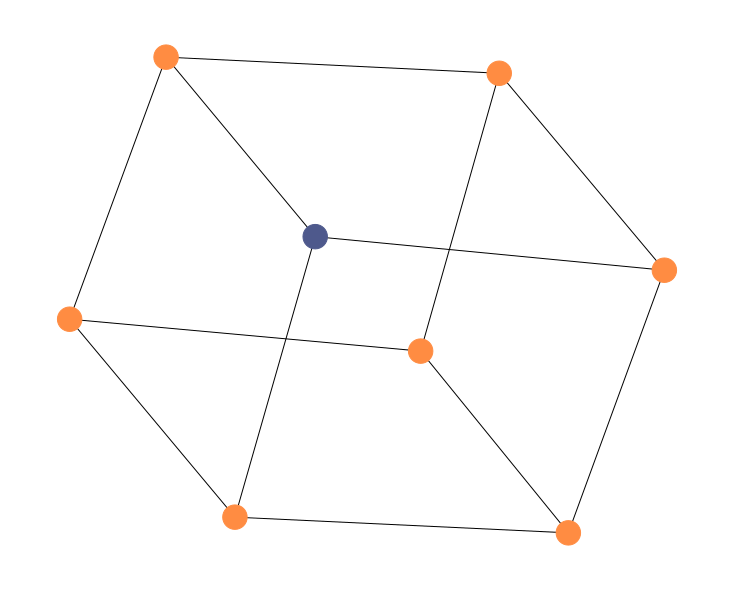

In [7]:
display_code("steane",steane["stabilizers"])

## Shor code

0


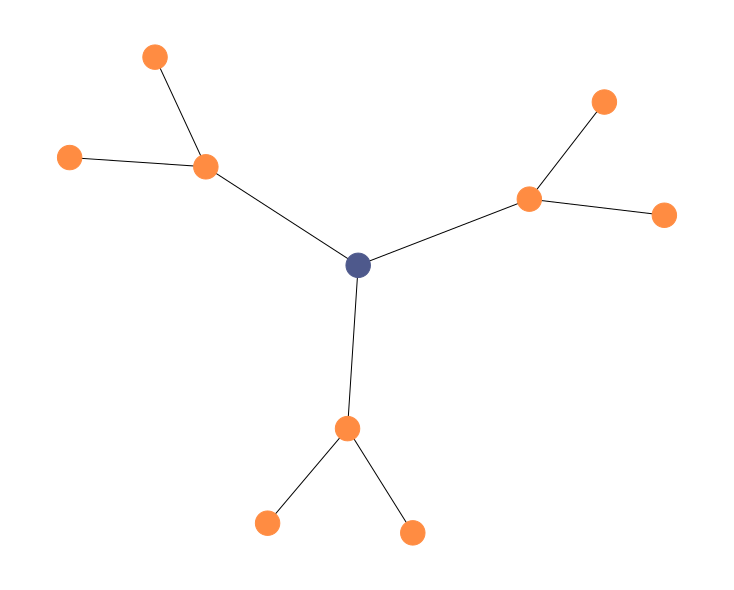

In [8]:
display_code("shor",shor_code["stabilizers"])

## 5 qubit code

0


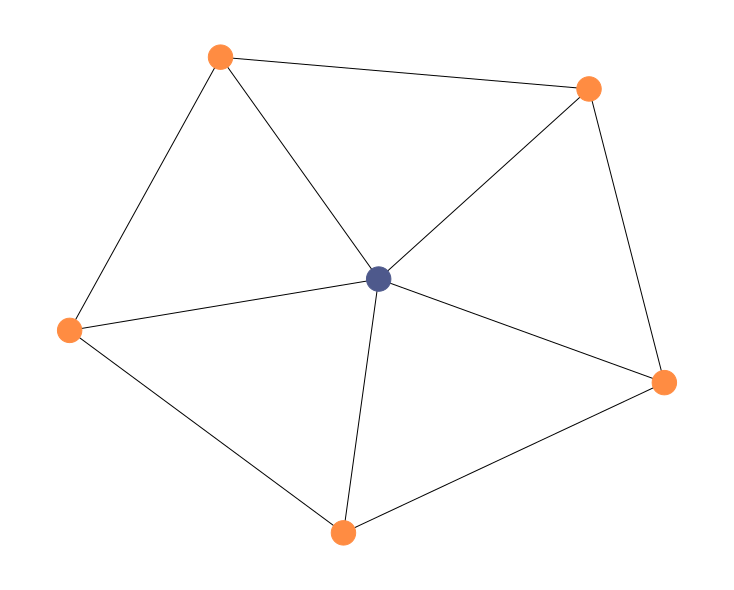

In [9]:
display_code("five_qubit",five_qubit["stabilizers"])

## Rotated surface code 3x3

0


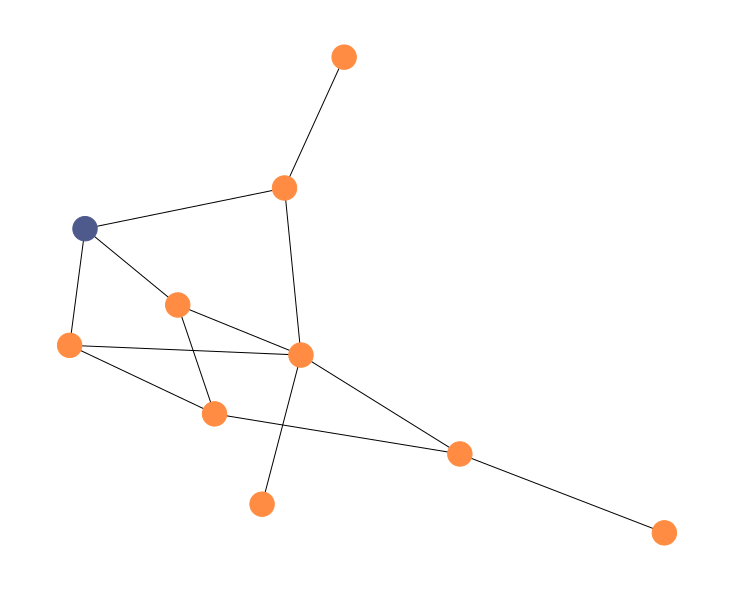

In [10]:
display_code("rotated",r3x3["stabilizers"])

## Toric Code 2x2

0
1


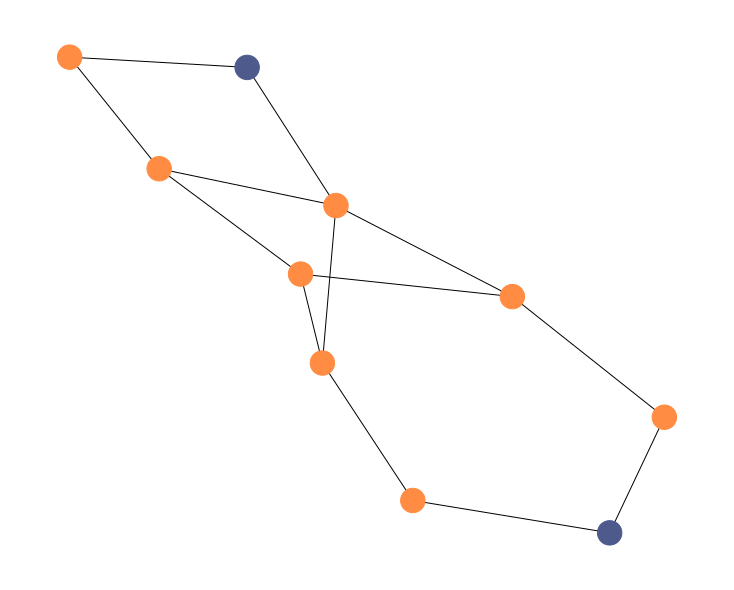

In [11]:
display_code("toric2x2", t2x2["stabilizers"])

## Toric Code 3x3

0
1


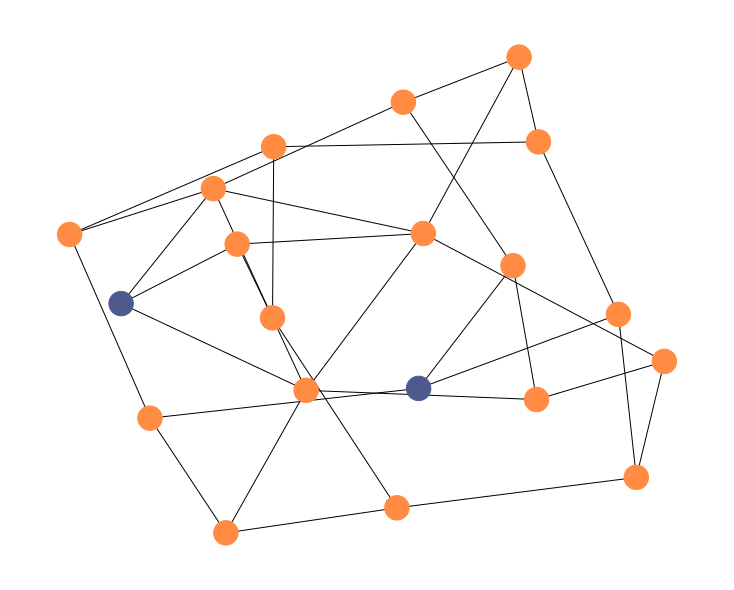

In [12]:
display_code("toric3x3",t3x3["stabilizers"])

## Shor code: steb by step

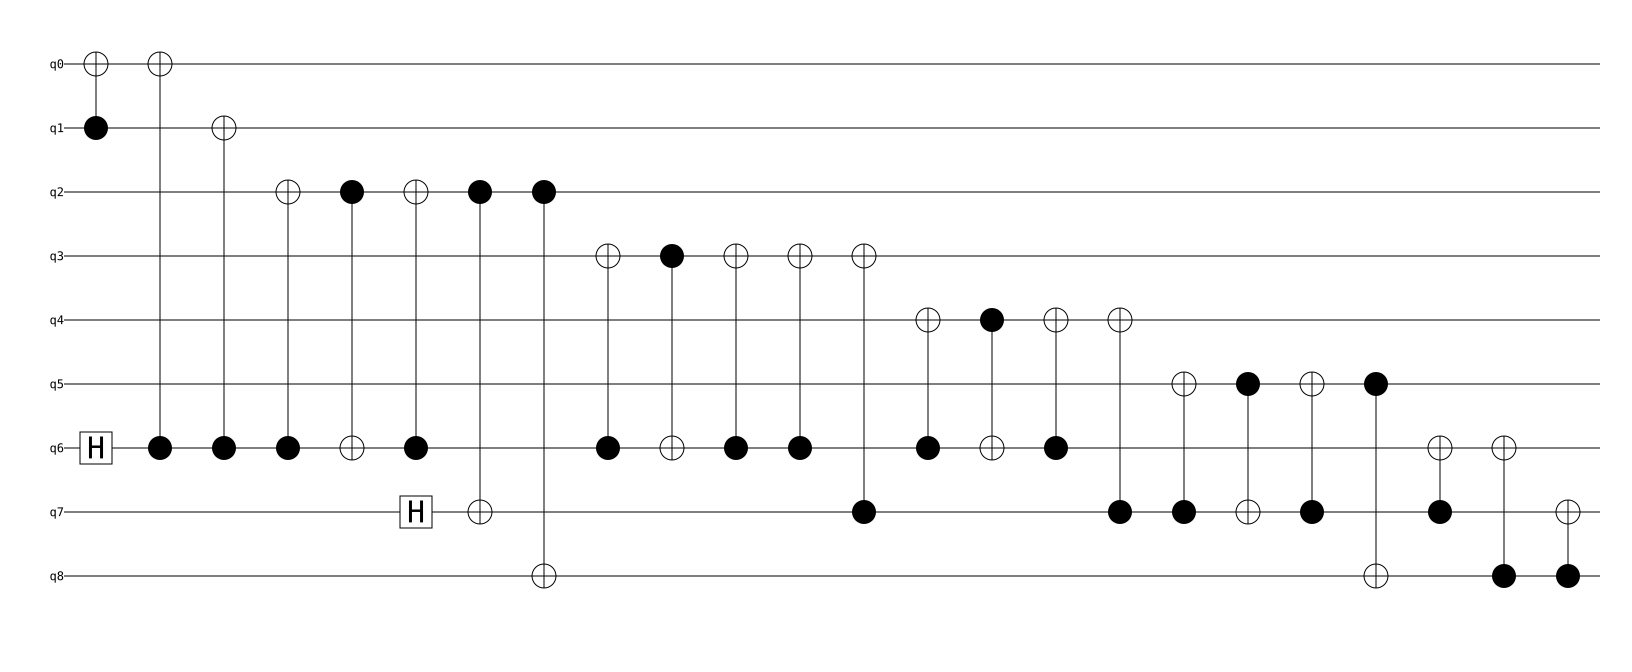

In [17]:
stabilizer_shor = shor_code["stabilizers"] 
n = shor_code["n"]
k = shor_code["k"]

stabilizers = [stim.PauliString(x) for x in stabilizer_shor]

tableau = stim.Tableau.from_stabilizers(stabilizers, allow_underconstrained=True)

shor_encoder = tableau.to_circuit(method = "elimination")

shor_encoder.diagram("timeline-svg")

In [29]:
shor_qasm = shor_encoder.to_qasm(open_qasm_version=3)
pyzx_shor = Circuit.from_qasm(shor_qasm).to_graph()
input_state =  "0"*(n - k)  + "/"*k
pyzx_shor.apply_state(input_state)
draw(pyzx_shor)

In [30]:
inputs = list(pyzx_shor.inputs())
shor_graph_state = GraphState(pyzx_shor)
draw(shor_graph_state.get_graph())

In [27]:
shor_graph_state.to_canonical_form()
draw(shor_graph_state.get_graph())

In [31]:
zxcf = graph_state_to_ZXCF(shor_graph_state, inputs)
draw(zxcf.graph)

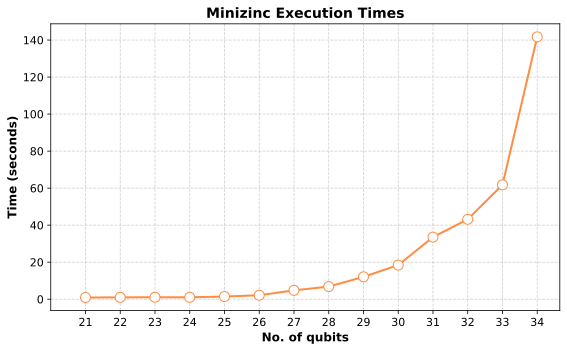

In [93]:
import matplotlib.pyplot as plt

times = []
with open("mzn_times2") as f:
    for l in f.readlines():
        times.append(float(l.strip()))

x_values = [x + 5 for x in range(len(times))]

target_ticks = [x for x in x_values if x > 20]
filtered_x = []
filtered_times = []

for x, t in zip(x_values, times):
    if x in target_ticks:
        filtered_x.append(x)
        filtered_times.append(t)

plt.figure(figsize=(8, 5)) # Set a good figure size

plt.plot(filtered_x, filtered_times, 
         marker='o',           
         markersize=10,
         linestyle='-',        
         linewidth=2,          
         color='#ff8c42',     
         markeredgecolor='#ff8c42',
         markerfacecolor="white",
         zorder=3)
# 5. Set the x-ticks to strictly 10, 20, 30
plt.xticks(target_ticks, fontsize=11)
plt.yticks(fontsize=11)

plt.xlim(left=20)
# 6. Add grid, labels, and title
plt.grid(True, linestyle='--', alpha=0.6, zorder=0) # Zorder 0 keeps the grid behind the points
plt.xlabel("No. of qubits", fontsize=12, fontweight='bold')
plt.ylabel("Time (seconds)", fontsize=12, fontweight='bold')
plt.title("Minizinc Execution Times", fontsize=14, fontweight='bold')

# Save or display the plot
plt.tight_layout() # Ensures nothing gets cut off
plt.savefig("polished_plot.png", dpi=300)
# plt.show() # Uncomment if you are running this in an interactive environment

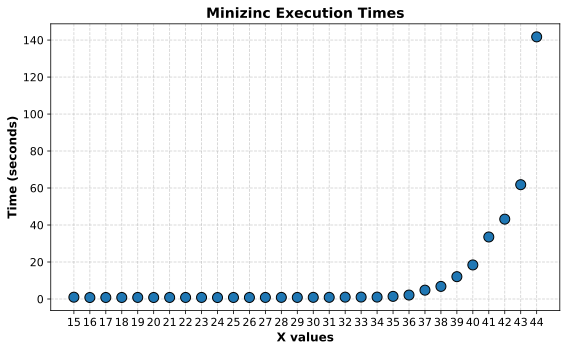

In [74]:
import matplotlib.pyplot as plt

# 1. Read the data using a list comprehension (cleaner and more Pythonic)
with open("mzn_times2") as f:
    times = [float(l.strip()) for l in f.readlines()]

# 2. Reconstruct the original x values
x_values = [x + 15 for x in range(len(times))]

# 3. Filter only the points where x is exactly 10, 20, or 30
target_ticks = x_values
filtered_x = []
filtered_times = []

for x, t in zip(x_values, times):
    if x in target_ticks:
        filtered_x.append(x)
        filtered_times.append(t)

# 4. Create a polished plot
plt.figure(figsize=(8, 5)) # Set a good figure size

# Plot the filtered points with a nice color, larger size (s), and edge color
plt.scatter(filtered_x, filtered_times, color='#1f77b4', s=100, edgecolor='black', zorder=3)

# 5. Set the x-ticks to strictly 10, 20, 30
plt.xticks(target_ticks, fontsize=11)
plt.yticks(fontsize=11)

# 6. Add grid, labels, and title
plt.grid(True, linestyle='--', alpha=0.6, zorder=0) # Zorder 0 keeps the grid behind the points
plt.xlabel("X values", fontsize=12, fontweight='bold')
plt.ylabel("Time (seconds)", fontsize=12, fontweight='bold')
plt.title("Minizinc Execution Times", fontsize=14, fontweight='bold')

# Save or display the plot
plt.tight_layout() # Ensures nothing gets cut off
plt.savefig("polished_plot.png", dpi=300)
# plt.show() # Uncomment if you are running this in an interactive environment